___
# **UNet Inpainting**
## Instructor -- Rizwan Ahmad (ahmad.46@osu.edu)
## BME5710 -- Spring 2026

**Network input/output:**
- Input: 2-channel tensor — channel 1 = masked image, channel 2 = binary mask (1=observed, 0=missing)
- Output: 1-channel reconstructed image (float32 in [0, 1])

**Folder structure (relative to this notebook):**
```
/content/drive/My Drive/Colab Notebooks/ (If running in colab)
  code_final.ipynb         ← this notebook
  train/                   ← 250 training TIFFs (train_000.tif ... train_249.tif)
  train_augemnted/         ← 2000 training TIFFs 
  test-masked/             ← 50 masked TIFFs + 50 binary mask TIFFs
  one_layer_model.pth      ← saved single layer CNN model weights
  best_model.pth           ← saved best model weights (created by this notebook)
  last_model.pth           ← saved last model weights (created by this notebook)
  submission.csv           ← Kaggle submission (created by this notebook)
```

___
### Import libraries

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image                                        # for reading TIFF files
from skimage.metrics import peak_signal_noise_ratio as skpsnr  # PSNR metric
from skimage.metrics import structural_similarity as skssim    # SSIM metric
import random

import torch
import torch.nn as nn                                        # neural network modules
from torch.utils.data import Dataset, DataLoader             # data handling utilities
import torchvision.transforms as transforms                  # for data augmentation


___
### Mounts drive for CoLab

In [ ]:
# if not os.path.ismount('/content/drive'):
#   from google.colab import drive
#   drive.mount('/content/drive')

___
### Predefine parameters

In [3]:
train_folder        = "train"          # folder with training TIFFs
test_masked_folder  = "test-masked"    # folder with masked test TIFFs
one_layer_path      = "one_layer_model.pth"    #Where the model for the single layer CNN is stored
checkpoint_path     = "best_model.pth"   #If you want to continue the model training on saved model
best_path           = "best_model.pth"    #Where it stores the best model from the training    #Be careful if don't want to override checkpoint path
last_path           = "last_model.pth"   #Where it stores the last model from the training
folder_path         = ""#"/content/drive/My Drive/Colab Notebooks/"    #Folder if using colab
imag_size           = 256              # image dimensions (H = W)
mask_ratio          = 0.75             # fraction of pixels that are missing
m_total             = len([f for f in os.listdir(folder_path + train_folder) if not f.startswith('.')])  # total number of images
m_tr                = int(m_total * 0.9)              # number of training images
m_val               = int(m_total * 0.1)               # number of validation images
m_te                = 50               # number of test images
batch_size          = 20                # mini-batch size
channel_number      = 128               #Number of intermediary channels for first layer of UNet
dropout_rate        = 0.1              # Dropout rate of UNet
learning_rate       = 1e-3
LR_factor           = 0.5
n_epochs            = 200               # number of training epochs
seed                = 0                # random seed for reproducibility

train_folder = folder_path + train_folder
test_masked_folder = folder_path + test_masked_folder
checkpoint_path = folder_path + checkpoint_path
last_path = folder_path + last_path
best_path = folder_path + best_path
one_layer_path = folder_path + one_layer_path

torch.manual_seed(seed)                # seed PyTorch RNG
np.random.seed(seed)                   # seed NumPy RNG

# Define data augmentations for training
# train_transform = transforms.Compose([
#     transforms.RandomHorizontalFlip(p=0.5),  # 50% chance to flip horizontally
#     transforms.RandomVerticalFlip(p=0.5),    # 50% chance to flip vertically
#     transforms.RandomRotation(degrees=180),   # Random rotation up to 180 degrees
#     # Add more augmentations as needed, e.g., transforms.RandomCrop, etc.
# ])
train_transform = None

# For validation, no augmentation (or minimal)
val_transform = None

DEVICE = torch.device("cpu")           # use CPU (change to "cuda" for GPU)
print(f"Using device: {DEVICE}")
if DEVICE != torch.device("cpu"):
    torch.zeros(1).cuda()

Using device: cpu


___
### Helper functions

In [11]:
# Helper function to list non-hidden files in a folder (ignoring .DS_Store and other dot-files).
def visible_files(folder):
    """Return non-hidden files in a folder (ignores .DS_Store and other dot-files)."""
    return [f for f in os.listdir(folder) if not f.startswith('.')]  # skip hidden files


# Compute the PSNR and competition metric (PSNR + 50×SSIM) for a batch of predictions and targets.
def compute_metrics(pred, target):
    """
    Compute PSNR and the competition metric (PSNR + 50×SSIM)
    averaged over a batch.
    """
    pred_np   = np.clip(pred.detach().cpu().numpy(), 0, 1)    # (B, 1, H, W), clamp to [0,1]
    target_np = np.clip(target.detach().cpu().numpy(), 0, 1) # (B, 1, H, W), clamp to [0,1]

    psnr_list   = []
    ssim_list   = []
    metric_list = []

    for i in range(pred_np.shape[0]):                        # loop over batch
        p = pred_np[i, 0]                                    # predicted image (H, W)
        t = target_np[i, 0]                                  # target image (H, W)

        psnr = skpsnr(t, p, data_range=1.0)                  # peak signal-to-noise ratio
        ssim = skssim(t, p, data_range=1.0)                  # structural similarity

        psnr_list.append(psnr)
        ssim_list.append(ssim)
        metric_list.append(psnr + 50.0 * ssim)               # competition metric

    return np.mean(psnr_list), np.mean(ssim_list), np.mean(metric_list)

def load_checkpoint(model, optimizer, filename=None):
    # Note: Input model & optimizer should be pre-defined.  This routine only updates their states.
    start_epoch = 0
    if os.path.isfile(filename):
        print("=> loading checkpoint '{}'".format(filename))
        checkpoint = torch.load(filename, weights_only=False, map_location=torch.device('cpu'))
        start_epoch = checkpoint['epoch']
        model.load_state_dict(checkpoint['state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        print("=> loaded checkpoint '{}' (epoch {})"
                  .format(filename, checkpoint['epoch']))
    else:
        print("=> no checkpoint found at '{}'".format(filename))

    return model, optimizer, start_epoch

___
### Load training images

In [5]:
def load_images(folder):
    """
    Load all TIFFs from a folder.
    Returns a list of float32 numpy arrays normalized to [0, 1].
    Handles both uint8 and uint16 source images automatically.
    """
    files = sorted([                                         # collect TIFF filenames
        f for f in visible_files(folder)
        if f.lower().endswith('.tif') or f.lower().endswith('.tiff')
    ])
    assert len(files) > 0, f"No TIFF files found in {folder}"

    images = []
    for fname in files:
        with Image.open(os.path.join(folder, fname)) as im:
            img = np.array(im)
        if img.dtype == np.uint16:                         # 16-bit → divide by 65535
            img = img.astype(np.float32) / 65535.0
        elif img.dtype == np.uint8:                        # 8-bit → divide by 255
            img = img.astype(np.float32) / 255.0
        else:                                                # already float → use as-is
            img = img.astype(np.float32)
        assert img.shape == (imag_size, imag_size), (
            f"Unexpected shape {img.shape} for {fname}; expected ({imag_size}, {imag_size})"
        )
        images.append(img)

    print(f"Loaded {len(images)} images from '{folder}'")
    return images


all_images = load_images(train_folder)                       # load all 250 images
assert len(all_images) == m_tr + m_val, (
    f"Expected {m_tr + m_val} images, found {len(all_images)}"
)

train_images = all_images[:m_tr]                             # first 225 for training
val_images   = all_images[m_tr:]                             # last 25 for validation
print(f"Split: {len(train_images)} train | {len(val_images)} validation")

Loaded 250 images from 'train'
Split: 225 train | 25 validation


___
### Dataset and DataLoader

In [6]:
class InpaintingDataset(Dataset):
    """
    For each image, applies data augmentation (if provided), then generates a fresh
    random i.i.d. Bernoulli mask every time the sample is accessed.

    Returns:
        masked_img : (1, H, W) float32 — full image with missing pixels zeroed out
        mask       : (1, H, W) float32 — binary mask (1=observed, 0=missing)
        full_img   : (1, H, W) float32 — ground-truth image (target)
    """
    def __init__(self, images, mask_ratio=0.75, transform=None):
        self.images     = images
        self.mask_ratio = mask_ratio
        self.transform  = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        full_img = self.images[idx]                          # (H, W) float32 in [0,1]

        # Apply data augmentation if provided
        if self.transform:
            # Convert to PIL Image for torchvision transforms
            pil_img = Image.fromarray((full_img * 255).astype(np.uint8), mode='L')
            pil_img = self.transform(pil_img)
            full_img = np.array(pil_img).astype(np.float32) / 255.0

        # i.i.d. Bernoulli mask: 1 = observed, 0 = missing
        mask = (np.random.rand(*full_img.shape) > self.mask_ratio).astype(np.float32)

        masked_img = full_img * mask                         # zero out missing pixels

        full_img   = torch.from_numpy(full_img[None])        # (H,W) → (1,H,W)
        masked_img = torch.from_numpy(masked_img[None])      # (H,W) → (1,H,W)
        mask       = torch.from_numpy(mask[None])            # (H,W) → (1,H,W)

        return masked_img, mask, full_img


train_dataset = InpaintingDataset(train_images, mask_ratio=mask_ratio, transform=train_transform)  # training set with augmentation
val_dataset   = InpaintingDataset(val_images,   mask_ratio=mask_ratio, transform=val_transform)    # validation set without augmentation

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)   # shuffle for training
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)  # no shuffle for validation

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 12 | Val batches: 2


___
### Built a custom loss function (Unused because backwards propagation didn't work)

In [7]:
class MetricLoss(nn.Module):
    def __init__(self):
        super(MetricLoss, self).__init__()

    def forward(self, pred, target):
        _, metric = compute_metrics(pred, target)
        loss = 100 - metric
        return loss

___
### Built the CNN model

In [8]:
class SingleLayerCNN(nn.Module):
    """
    Single convolutional layer for inpainting.
    Input:  2-channel tensor (masked image + binary mask)
    Output: 1-channel reconstructed image
    """
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels=2,       # masked image + mask
            out_channels=1,      # single-channel output
            kernel_size=3,
            padding=1            # same padding to preserve spatial dimensions
        )
        self.sigmoid = nn.Sigmoid()                          # clamp output to [0, 1]

    def forward(self, masked_img, mask):
        x = torch.cat([masked_img, mask], dim=1)             # (B, 2, H, W)
        x = self.conv(x)     # (B, 1, H, W)
        x = self.sigmoid(x)                                  # (B, 1, H, W) in [0,1]
        return x

class UNet(nn.Module):
    """
    UNet for inpainting.
    Input:  2-channel tensor (masked image + binary mask)
    Output: 1-channel reconstructed image
    """
    def __init__(self, channel_number=64, dropout_rate=0.5):
        super().__init__()
        self.chan = channel_number    #The number of intermediate channels for layer 1
        self.ReLU = nn.ReLU()       #ReLU after 3x3 convolutions
        self.dropout_rate = dropout_rate

        #Layer 1 down
        self.conv1 = nn.Conv2d(
            in_channels=2,       # masked image + mask
            out_channels=self.chan,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn1 = nn.BatchNorm2d(self.chan)
        self.dropout1 = nn.Dropout2d(p=dropout_rate)
        self.conv2 = nn.Conv2d(
            in_channels=self.chan,       # intermediate
            out_channels=self.chan,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn2 = nn.BatchNorm2d(self.chan)
        self.dropout2 = nn.Dropout2d(p=dropout_rate)
        self.maxpool1 = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
            padding=0            # same padding to preserve spatial dimensions
        )

        #Layer 2 down
        self.conv3 = nn.Conv2d(
            in_channels=self.chan,
            out_channels=self.chan*2,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn3 = nn.BatchNorm2d(self.chan*2)
        self.dropout3 = nn.Dropout2d(p=dropout_rate)
        self.conv4 = nn.Conv2d(
            in_channels=self.chan*2,       # intermediate
            out_channels=self.chan*2,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn4 = nn.BatchNorm2d(self.chan*2)
        self.dropout4 = nn.Dropout2d(p=dropout_rate)
        self.maxpool2 = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
            padding=0            # same padding to preserve spatial dimensions
        )

        #Layer 3 down
        self.conv5 = nn.Conv2d(
            in_channels=self.chan*2,
            out_channels=self.chan*4,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn5 = nn.BatchNorm2d(self.chan*4)
        self.dropout5 = nn.Dropout2d(p=dropout_rate)
        self.conv6 = nn.Conv2d(
            in_channels=self.chan*4,       # intermediate
            out_channels=self.chan*4,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn6 = nn.BatchNorm2d(self.chan*4)
        self.dropout6 = nn.Dropout2d(p=dropout_rate)
        self.maxpool3 = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
            padding=0            # same padding to preserve spatial dimensions
        )

        #Layer 4 down
        self.conv7 = nn.Conv2d(
            in_channels=self.chan*4,
            out_channels=self.chan*8,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn7 = nn.BatchNorm2d(self.chan*8)
        self.dropout7 = nn.Dropout2d(p=dropout_rate)
        self.conv8 = nn.Conv2d(
            in_channels=self.chan*8,       # intermediate
            out_channels=self.chan*8,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn8 = nn.BatchNorm2d(self.chan*8)
        self.dropout8 = nn.Dropout2d(p=dropout_rate)
        self.maxpool4 = nn.MaxPool2d(
            kernel_size=2,
            stride=2,
            padding=0            # same padding to preserve spatial dimensions
        )

        #Layer 5 pinch point
        self.conv9 = nn.Conv2d(
            in_channels=self.chan*8,
            out_channels=self.chan*16,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn9 = nn.BatchNorm2d(self.chan*16)
        self.dropout9 = nn.Dropout2d(p=dropout_rate)
        self.conv10 = nn.Conv2d(
            in_channels=self.chan*16,       # intermediate
            out_channels=self.chan*16,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn10 = nn.BatchNorm2d(self.chan*16)
        self.dropout10 = nn.Dropout2d(p=dropout_rate)

        #Layer 5 up
        self.upconv1 = nn.ConvTranspose2d(
            in_channels=self.chan*16,
            out_channels=self.chan*8,
            kernel_size=2,
            stride=2        #Maintains original size (H_in-1)*stride + dilation(kernel-1) + 1
        )
        self.conv11 = nn.Conv2d(
            in_channels=self.chan*16,
            out_channels=self.chan*8,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn11 = nn.BatchNorm2d(self.chan*8)
        self.dropout11 = nn.Dropout2d(p=dropout_rate)
        self.conv12 = nn.Conv2d(
            in_channels=self.chan*8,       # intermediate
            out_channels=self.chan*8,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn12 = nn.BatchNorm2d(self.chan*8)
        self.dropout12 = nn.Dropout2d(p=dropout_rate)

        #Layer 4 up
        self.upconv2 = nn.ConvTranspose2d(
            in_channels=self.chan*8,
            out_channels=self.chan*4,
            kernel_size=2,
            stride=2        #Maintains original size (H_in-1)*stride + dilation(kernel-1) + 1
        )
        self.conv13 = nn.Conv2d(
            in_channels=self.chan*8,
            out_channels=self.chan*4,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn13 = nn.BatchNorm2d(self.chan*4)
        self.dropout13 = nn.Dropout2d(p=dropout_rate)
        self.conv14 = nn.Conv2d(
            in_channels=self.chan*4,       # intermediate
            out_channels=self.chan*4,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn14 = nn.BatchNorm2d(self.chan*4)
        self.dropout14 = nn.Dropout2d(p=dropout_rate)

        #Layer 3 up
        self.upconv3 = nn.ConvTranspose2d(
            in_channels=self.chan*4,
            out_channels=self.chan*2,
            kernel_size=2,
            stride=2        #Maintains original size (H_in-1)*stride + dilation(kernel-1) + 1
        )
        self.conv15 = nn.Conv2d(
            in_channels=self.chan*4,
            out_channels=self.chan*2,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn15 = nn.BatchNorm2d(self.chan*2)
        self.dropout15 = nn.Dropout2d(p=dropout_rate)
        self.conv16 = nn.Conv2d(
            in_channels=self.chan*2,       # intermediate
            out_channels=self.chan*2,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn16 = nn.BatchNorm2d(self.chan*2)
        self.dropout16 = nn.Dropout2d(p=dropout_rate)

        #Layer 2 up
        self.upconv4 = nn.ConvTranspose2d(
            in_channels=self.chan*2,
            out_channels=self.chan,
            kernel_size=2,
            stride=2        #Maintains original size (H_in-1)*stride + dilation(kernel-1) + 1
        )
        self.conv17 = nn.Conv2d(
            in_channels=self.chan*2,
            out_channels=self.chan,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn17 = nn.BatchNorm2d(self.chan)
        self.dropout17 = nn.Dropout2d(p=dropout_rate)
        self.conv18 = nn.Conv2d(
            in_channels=self.chan,       # intermediate
            out_channels=self.chan,     # intermediate channel size
            kernel_size=3,
            padding=1,            # same padding to preserve spatial dimensions
            bias=False
        )
        self.bn18 = nn.BatchNorm2d(self.chan)
        self.dropout18 = nn.Dropout2d(p=dropout_rate)

        #Layer 1 output
        self.conv19 = nn.Conv2d(
            in_channels=self.chan,
            out_channels=1,
            kernel_size=1,
            padding=0
        )
        self.sigmoid = nn.Sigmoid()                          # clamp output to [0, 1]


    def forward(self, masked_img, mask):
        x = torch.cat([masked_img, mask], dim=1)             # (B, 2, H, W)

        x = self.ReLU(self.dropout1(self.bn1(self.conv1(x))))    # (B, 64, H, W)
        x = self.ReLU(self.dropout2(self.bn2(self.conv2(x))))    # (B, 64, H, W)
        identity1 = x
        x = self.maxpool1(x) # (B, 64, H/2, W/2)

        x = self.ReLU(self.dropout3(self.bn3(self.conv3(x))))    # (B, 128, H/2, W/2)
        x = self.ReLU(self.dropout4(self.bn4(self.conv4(x))))    # (B, 128, H/2, W/2)
        identity2 = x
        x = self.maxpool2(x) # (B, 128, H/4, W/4)

        x = self.ReLU(self.dropout5(self.bn5(self.conv5(x))))    # (B, 256, H/4, W/4)
        x = self.ReLU(self.dropout6(self.bn6(self.conv6(x))))    # (B, 256, H/4, W/4)
        identity3 = x
        x = self.maxpool3(x) # (B, 256, H/8, W/8)

        x = self.ReLU(self.dropout7(self.bn7(self.conv7(x))))    # (B, 512, H/8, W/8)
        x = self.ReLU(self.dropout8(self.bn8(self.conv8(x))))    # (B, 512, H/8, W/8)
        identity4 = x
        x = self.maxpool4(x) # (B, 512, H/16, W/16)

        x = self.ReLU(self.dropout9(self.bn9(self.conv9(x))))    # (B, 1024, H/16, W/16)
        x = self.ReLU(self.dropout10(self.bn10(self.conv10(x))))   # (B, 1024, H/16, W/16)

        x = torch.cat([identity4, self.upconv1(x)], dim=1)  # (B, 1024, H/8, W/8)
        x = self.ReLU(self.dropout11(self.bn11(self.conv11(x))))   # (B, 512, H/8, W/8)
        x = self.ReLU(self.dropout12(self.bn12(self.conv12(x))))   # (B, 512, H/8, W/8)

        x = torch.cat([identity3, self.upconv2(x)], dim=1)  # (B, 512, H/4, W/4)
        x = self.ReLU(self.dropout13(self.bn13(self.conv13(x))))   # (B, 256, H/4, W/4)
        x = self.ReLU(self.dropout14(self.bn14(self.conv14(x))))   # (B, 256, H/4, W/4)

        x = torch.cat([identity2, self.upconv3(x)], dim=1)  # (B, 256, H/2, W/2)
        x = self.ReLU(self.dropout15(self.bn15(self.conv15(x))))   # (B, 128, H/2, W/2)
        x = self.ReLU(self.dropout16(self.bn16(self.conv16(x))))   # (B, 128, H/2, W/2)

        x = torch.cat([identity1, self.upconv4(x)], dim=1)  # (B, 128, H, W)
        x = self.ReLU(self.dropout17(self.bn17(self.conv17(x))))   # (B, 64, H, W)
        x = self.ReLU(self.dropout18(self.bn18(self.conv18(x))))   # (B, 64, H, W)

        x = self.conv19(x)   # (B, 1, H, W)
        x = self.sigmoid(x)                                  # (B, 1, H, W) in [0,1]
        return x

model     = UNet(channel_number=channel_number, dropout_rate=dropout_rate).to(DEVICE)                      # instantiate and move to device
criterion = nn.MSELoss()                                     # mean squared error loss
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)    # Adam optimizer
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=LR_factor, patience=5)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model initialized. Trainable parameters: {n_params}")

Model initialized. Trainable parameters: 124120321


___
### Training loop

In [ ]:
#Set best validation metric as min possible value
best_val_metric = 0

start_epoch = 1
if os.path.isfile(checkpoint_path):
    model, optimizer, start_epoch = load_checkpoint(model, optimizer, checkpoint_path)
    model = model.to(DEVICE)
    # now individually transfer the optimizer parts...
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(DEVICE)
    print(f"Resuming training from epoch {start_epoch}")
else:
    print("Training from scratch")

print(f"{'Epoch':>5} | {'Train Loss':>12} | {'Train Metric':>14} | {'Val Loss':>10} | {'Val Metric':>12}")
print("-" * 65)

for epoch in range(start_epoch, n_epochs + start_epoch):
    flag = ""
    # ── Training ─────────────────────────────────────────────────────────────
    model.train()                                            # set model to training mode
    train_loss_sum   = 0.0
    train_metric_sum = 0.0
    train_n          = 0

    for masked_img, mask, full_img in train_loader:          # iterate over mini-batches
        masked_img = masked_img.to(DEVICE)
        mask       = mask.to(DEVICE)
        full_img   = full_img.to(DEVICE)

        optimizer.zero_grad()                                # reset gradients
        pred = model(masked_img, mask)                       # forward pass → (B, 1, H, W)
        loss = criterion(pred, full_img)                     # compute MSE loss
        loss.backward()                                      # backpropagation
        optimizer.step()                                     # update weights

        batch_size = full_img.shape[0]
        _, _, batch_metric = compute_metrics(pred, full_img)    # PSNR + 50×SSIM
        train_loss_sum   += loss.item() * batch_size
        train_metric_sum += batch_metric * batch_size
        train_n          += batch_size

    train_loss   = train_loss_sum   / train_n                # average training loss
    train_metric = train_metric_sum / train_n                # average training metric

    # ── Validation ───────────────────────────────────────────────────────────
    model.eval()                                             # set model to eval mode
    val_loss_sum   = 0.0
    val_metric_sum = 0.0
    val_n          = 0

    with torch.no_grad():                                    # disable gradient tracking
        for masked_img, mask, full_img in val_loader:
            masked_img = masked_img.to(DEVICE)
            mask       = mask.to(DEVICE)
            full_img   = full_img.to(DEVICE)

            pred = model(masked_img, mask)                   # forward pass
            loss = criterion(pred, full_img)                 # compute loss

            batch_size = full_img.shape[0]
            _, _, batch_metric = compute_metrics(pred, full_img)
            val_loss_sum   += loss.item() * batch_size
            val_metric_sum += batch_metric * batch_size
            val_n          += batch_size

    val_loss   = val_loss_sum   / val_n                      # average validation loss
    val_metric = val_metric_sum / val_n                      # average validation metric

    #Save if best model
    if val_metric > best_val_metric:
        best_val_metric = val_metric
        state = {'epoch': epoch, 'state_dict': model.state_dict(), 'optimizer': optimizer.state_dict(), }
        torch.save(state, best_path)
        flag = "NEW BEST"

    # Update learning rate scheduler based on validation loss plateau
    scheduler.step(val_loss)

    print(f"{epoch:>5} | {train_loss:>12.6f} | {train_metric:>14.4f} | {val_loss:>10.6f} | {val_metric:>12.4f} | {flag}")
# print out the min/max values for the recovered images

=> loading checkpoint '/content/drive/My Drive/Colab Notebooks/best_model.pth'
=> loaded checkpoint '/content/drive/My Drive/Colab Notebooks/best_model.pth' (epoch 173)
Resuming training from epoch 173
Epoch |   Train Loss |   Train Metric |   Val Loss |   Val Metric
-----------------------------------------------------------------
  173 |     0.000561 |        79.1221 |   0.000522 |      80.0534 | NEW BEST
  174 |     0.000563 |        79.1078 |   0.000522 |      80.0333 | 


___
### Save the model

In [12]:
try:
    print(f"Best Model saved to {best_path} with metric of {best_val_metric}")

    torch.save(model.state_dict(), last_path)                  # save learned weights
    print(f"Model saved to {last_path}")
except:
    print("Training Loop hasn't run")


#Gets best model during training
best_model = UNet(channel_number=channel_number, dropout_rate=dropout_rate).to(DEVICE)    #Creates blank UNet
best_model, _, _ = load_checkpoint(model, optimizer, best_path)             #Loads model parameters via file
best_model = best_model.to(DEVICE)                                                       #Moves model to device or smthing

#Gets single layer model
one_layer_model = SingleLayerCNN().to(DEVICE)    #Creates blank single layer CNN
one_layer_model.load_state_dict(torch.load(one_layer_path, map_location=torch.device('cpu')))             #Loads model parameters via file
one_layer_model = one_layer_model.to(DEVICE)                                                       #Moves model to device or sm
print("Loaded single layer model")

Training Loop hasn't run
=> loading checkpoint 'best_model.pth'
=> loaded checkpoint 'best_model.pth' (epoch 173)
Loaded single layer model


___
### Calculates training and validation metrics for trivial model, single layer model, and final model

In [19]:
def get_metrics_train(model, dataloader):
    if model is not None:
        model.train()                                            # set model to training mode
    train_psnr_sum = 0.0
    train_ssim_sum = 0.0
    train_metric_sum = 0.0
    train_n          = 0

    with torch.no_grad():                                    # disable gradient tracking
        for masked_img, mask, full_img in dataloader:          # iterate over mini-batches
            masked_img = masked_img.to(DEVICE)
            mask       = mask.to(DEVICE)
            full_img   = full_img.to(DEVICE)
            if model is not None:
                pred = model(masked_img, mask)                       # forward pass → (B, 1, H, W)
            else:
                pred = masked_img

            batch_size = full_img.shape[0]
            batch_psnr, batch_ssim, batch_metric = compute_metrics(pred, full_img)    # PSNR + 50×SSIM
            train_psnr_sum += batch_psnr * batch_size
            train_ssim_sum += batch_ssim * batch_size
            train_metric_sum += batch_metric * batch_size
            train_n          += batch_size

    train_psnr = train_psnr_sum / train_n                # average training metric
    train_ssim = train_ssim_sum / train_n
    train_metric = train_metric_sum / train_n
    return (train_psnr, train_ssim, train_metric)

def get_metrics_val(model, dataloader):
    if model is not None:
        model.eval()                                              # set model to eval mode
    val_psnr_sum = 0.0
    val_ssim_sum = 0.0
    val_metric_sum = 0.0
    val_n          = 0

    with torch.no_grad():                                    # disable gradient tracking
        for masked_img, mask, full_img in dataloader:
            masked_img = masked_img.to(DEVICE)
            mask       = mask.to(DEVICE)
            full_img   = full_img.to(DEVICE)

            if model is not None:
                pred = model(masked_img, mask)                       # forward pass → (B, 1, H, W)
            else:
                pred = masked_img

            batch_size = full_img.shape[0]
            batch_psnr, batch_ssim, batch_metric = compute_metrics(pred, full_img)
            val_psnr_sum += batch_psnr * batch_size
            val_ssim_sum += batch_ssim * batch_size
            val_metric_sum += batch_metric * batch_size
            val_n          += batch_size

    val_psnr = val_psnr_sum / val_n
    val_ssim = val_ssim_sum / val_n
    val_metric = val_metric_sum / val_n                      # average validation metric
    return (val_psnr, val_ssim, val_metric)

print("Trivial Inpainting")
print("Method | PSNR  | SSIM  |PSNR + 50*SSIM")
metrics = get_metrics_train(None, train_loader)
print("Train  |%6.3f |%6.3f | %6.3f " % metrics)
metrics = get_metrics_val(None, val_loader)
print("Val    |%6.3f |%6.3f | %6.3f " % metrics)
print()

print("Single Layer CNN")
print("Method | PSNR  | SSIM  |PSNR + 50*SSIM")
metrics = get_metrics_train(one_layer_model, train_loader)
print("Train  |%6.3f |%6.3f | %6.3f " % metrics)
metrics = get_metrics_val(one_layer_model, val_loader)
print("Val    |%6.3f |%6.3f | %6.3f " % metrics)
print()

print("Final CNN")
print("Method | PSNR  | SSIM  |PSNR + 50*SSIM")
metrics = get_metrics_train(best_model, train_loader)
print("Train  |%6.3f |%6.3f | %6.3f " % metrics)
metrics = get_metrics_val(best_model, val_loader)
print("Val    |%6.3f |%6.3f | %6.3f " % metrics)


Trivial Inpainting
Method | PSNR  | SSIM  |PSNR + 50*SSIM
Train  |13.342 | 0.224 | 24.541 
Val    |13.216 | 0.219 | 24.159 

Single Layer CNN
Method | PSNR  | SSIM  |PSNR + 50*SSIM
Train  |20.821 | 0.492 | 45.446 
Val    |20.647 | 0.487 | 45.021 

Final CNN
Method | PSNR  | SSIM  |PSNR + 50*SSIM
Train  |32.625 | 0.928 | 79.000 
Val    |32.970 | 0.942 | 80.067 


___
### Visualize UNet with single layer CNN

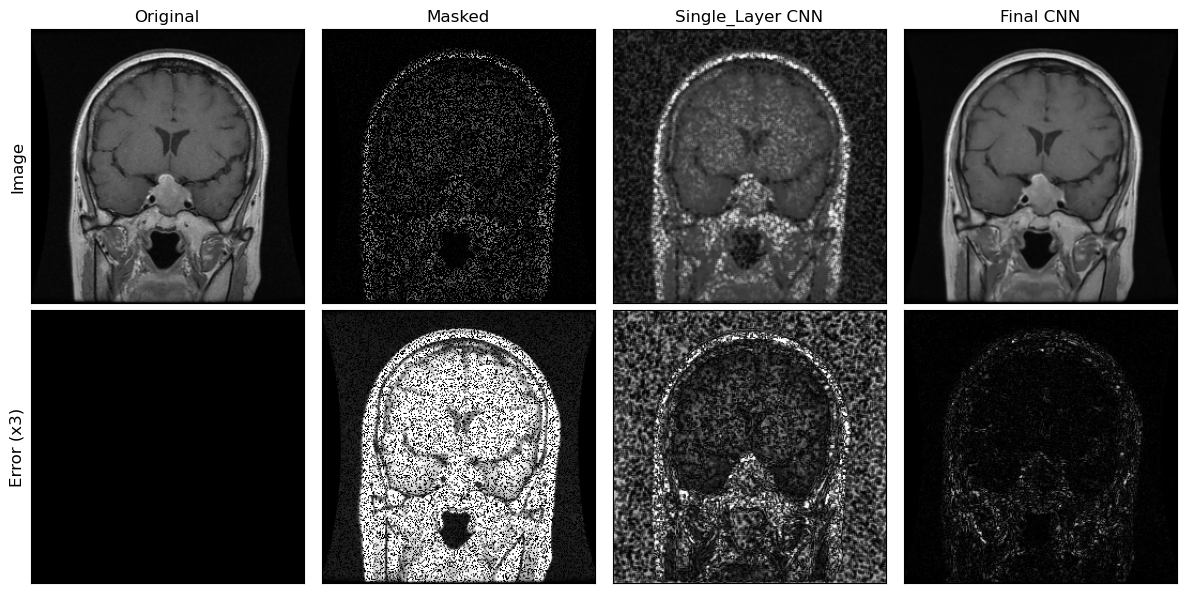

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))             # 2 rows × 4 columns
best_model.eval()
one_layer_model.eval()

idx = random.randint(0, len(val_dataset) - 1)                # pick a random sample
masked_img, mask, full_img = val_dataset[idx]                # each (1, H, W)

with torch.no_grad():                                    # no gradients needed
    best_rec = best_model(masked_img[None].to(DEVICE), mask[None].to(DEVICE)).cpu()
    one_layer_rec = one_layer_model(masked_img[None].to(DEVICE), mask[None].to(DEVICE)).cpu()

orig   = full_img[0].numpy()                             # ground truth
masked = masked_img[0].numpy()                           # masked input
best_rec    = best_rec[0, 0].numpy()                         # model output
one_layer_rec = one_layer_rec[0, 0].numpy()                         # model output

orig_err    = np.abs(orig - orig) * 3                          # amplified error map
masked_err    = np.abs(orig - masked) * 3                          # amplified error map
best_err    = np.abs(orig - best_rec) * 3                          # amplified error map
one_layer_err = np.abs(orig - one_layer_rec) * 3                          # amplified error map

for i in range(2):
    for j in range(4):
        img = [[orig, masked, one_layer_rec, best_rec], [orig_err, masked_err, one_layer_err, best_err]][i][j]
        axes[i, j].imshow(img, cmap="gray", vmin=0, vmax=1)
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        if i == 0:
            axes[i, j].set_title(["Original", "Masked", "Single_Layer CNN", "Final CNN"][j], fontsize=12)
        if j == 0:
            axes[i, j].set_ylabel(["Image", "Error (x3)"][i], fontsize=12)
    
plt.tight_layout()
plt.show()

___
### Visualize results

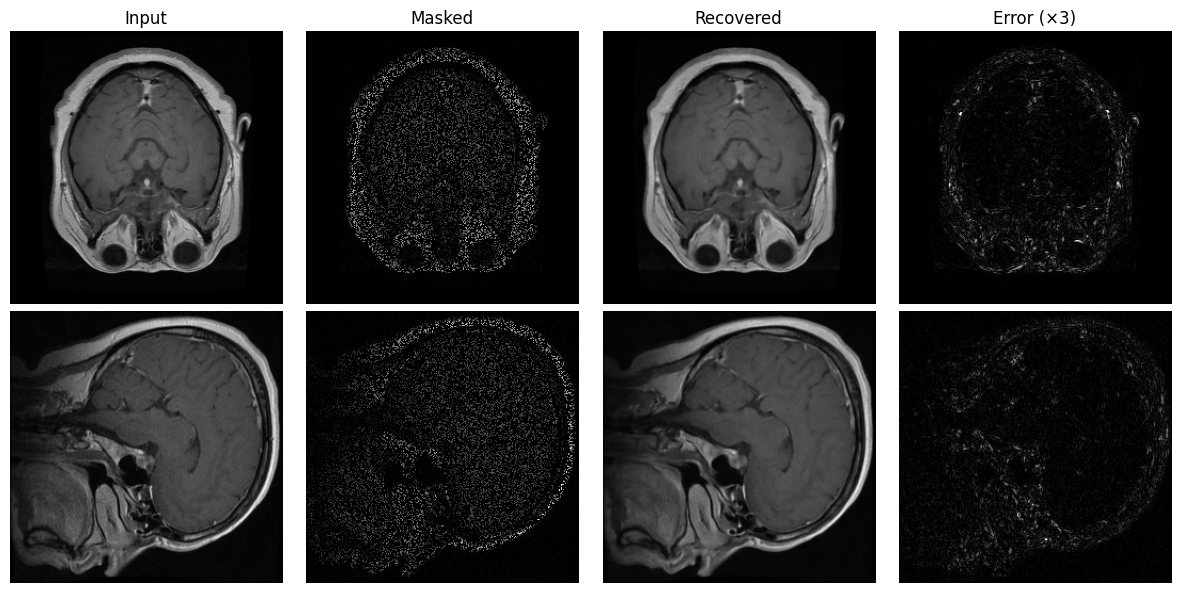

In [33]:
import random

fig, axes = plt.subplots(2, 4, figsize=(12, 6))             # 2 rows × 4 columns
best_model.eval()

for row, dataset in enumerate([train_dataset, val_dataset]): # row 0 = train, row 1 = val
    idx = random.randint(0, len(dataset) - 1)                # pick a random sample
    masked_img, mask, full_img = dataset[idx]                # each (1, H, W)

    with torch.no_grad():                                    # no gradients needed
        recovered = best_model(masked_img[None].to(DEVICE), mask[None].to(DEVICE)).cpu()

    orig   = full_img[0].numpy()                             # ground truth
    masked = masked_img[0].numpy()                           # masked input
    rec    = recovered[0, 0].numpy()                         # model output
    err    = np.abs(orig - rec) * 3                          # amplified error map

    for ax, img, title in zip(axes[row], [orig, masked, rec, err],
                               ["Input", "Masked", "Recovered", "Error (×3)"]):
        ax.imshow(img, cmap="gray", vmin=0, vmax=1)
        if row == 0:
            ax.set_title(title)
        ax.axis("off")

axes[0, 0].set_ylabel("Train", fontsize=12)
axes[1, 0].set_ylabel("Val", fontsize=12)
plt.tight_layout()
plt.show()

___
### Inference on test images

Load each masked test image and its binary mask from `test-masked/`, run the trained
network, and stack the reconstructions into a single `(50, 256, 256)` float32 array
saved as `submission.csv`.

**Note:** The `_mask.tif` files were saved with pixel values 0/255. We divide by 255
when loading to recover the 0/1 float mask expected by the network.

Found 50 masked test images and 50 mask files.


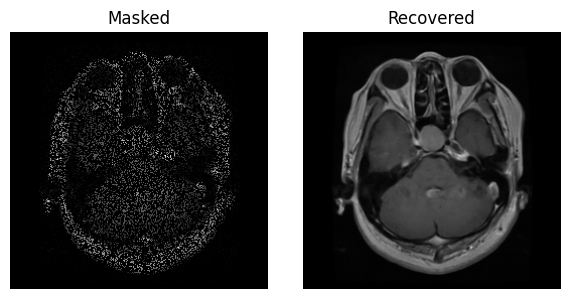

In [34]:
def load_test_sample(masked_path, mask_path):
    """
    Load a masked test image and its binary mask.
    Returns tensors ready for model input: (1, 1, H, W).
    """
    with Image.open(masked_path) as im:
        masked_img = np.array(im)
    if masked_img.dtype == np.uint16:                        # 16-bit → divide by 65535
        masked_img = masked_img.astype(np.float32) / 65535.0
    elif masked_img.dtype == np.uint8:                       # 8-bit → divide by 255
        masked_img = masked_img.astype(np.float32) / 255.0
    else:                                                    # already float → use as-is
        masked_img = masked_img.astype(np.float32)

    with Image.open(mask_path) as im:
        mask = np.array(im).astype(np.float32) / 255.0       # 0/255 uint8 → 0/1 float

    masked_img = torch.from_numpy(masked_img[None, None])    # (H,W) → (1,1,H,W)
    mask       = torch.from_numpy(mask[None, None])          # (H,W) → (1,1,H,W)

    return masked_img, mask


# Collect and sort masked images and their corresponding masks
all_test_files = sorted([
    f for f in visible_files(test_masked_folder)
    if f.lower().endswith('.tif') or f.lower().endswith('.tiff')
])

masked_files = [f for f in all_test_files if f.endswith('_masked.tif')]  # input images
mask_files   = [f for f in all_test_files if f.endswith('_mask.tif')]    # binary masks

assert len(masked_files) == m_te, f"Expected {m_te} masked images, found {len(masked_files)}"
assert len(mask_files)   == m_te, f"Expected {m_te} mask files, found {len(mask_files)}"

print(f"Found {len(masked_files)} masked test images and {len(mask_files)} mask files.")

# Run inference
best_model.eval()
reconstructions = []

with torch.no_grad():                                        # no gradients for inference
    for masked_fname, mask_fname in zip(masked_files, mask_files):
        masked_img, mask = load_test_sample(
            os.path.join(test_masked_folder, masked_fname),
            os.path.join(test_masked_folder, mask_fname)
        )
        masked_img = masked_img.to(DEVICE)
        mask       = mask.to(DEVICE)

        pred = best_model(masked_img, mask)                       # forward pass → (1,1,H,W)
        pred = pred.squeeze().cpu().numpy()                  # → (H, W)
        pred = np.clip(pred, 0.0, 1.0)                       # clamp to [0, 1]
        reconstructions.append(pred)

# Plot a random test sample
idx = random.randint(0, len(reconstructions) - 1)
test_masked = Image.open(os.path.join(test_masked_folder, masked_files[idx]))
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(np.array(test_masked).astype(np.float32), cmap="gray")
axes[0].set_title("Masked"); axes[0].axis("off")
axes[1].imshow(reconstructions[idx], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Recovered"); axes[1].axis("off")
plt.tight_layout()
plt.show()

___
### Prepare `submission.csv` to upload on Kaggle

In [35]:
# Flatten each (256, 256) reconstruction into a row of 65536 pixels
pixel_cols = [f"pixel_{j}" for j in range(imag_size * imag_size)]
rows = [rec.ravel() for rec in reconstructions]

submission_df = pd.DataFrame(rows, columns=pixel_cols, dtype=np.float32)
submission_df.insert(0, "id", [f"img_{i:03d}" for i in range(m_te)])

submission_df.to_csv(folder_path + "submission.csv", index=False)

print(f"Submission saved to submission.csv")
print(f"  Shape : {submission_df.shape}")
print(f"  Range : [{submission_df[pixel_cols].min().min():.4f}, {submission_df[pixel_cols].max().max():.4f}]")

Submission saved to submission.csv
  Shape : (50, 65537)
  Range : [0.0000, 0.9316]
